# Modèle 2 — Random Forest


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix,
    roc_curve, mean_absolute_error, 
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer


Imports OK


## Chargement des données preprocessées

Mêmes données que pour la Régression Logistique.
On charge les fichiers .npy générés par le preprocessing.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Labels originaux (pour référence et régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# y_train_reg_log chargé plus bas dans la section régression
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (undersampling)")
print(f"   X_train_smote   : {X_train_smote.shape} (SMOTE)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (undersampling)
   X_train_smote   : (14366, 50) (SMOTE)
   X_test          : (2000, 50)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification du Churn

On entraîne le Random Forest sur **deux datasets** : Undersampling et SMOTE, puis on compare les métriques.

In [3]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
rf_clf_under = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_under.fit(X_train_under, y_train_clf_under)
y_pred_under  = rf_clf_under.predict(X_test)
y_proba_under = rf_clf_under.predict_proba(X_test)[:, 1]

print("=== Random Forest — Undersampling ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_under):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_under):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_under):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_under):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_under):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_under):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
rf_clf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = rf_clf_smote.predict(X_test)
y_proba_smote = rf_clf_smote.predict_proba(X_test)[:, 1]

print("=== Random Forest — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_smote):.4f}")

# On garde le meilleur basé sur le Recall
recall_under = recall_score(y_test_clf, y_pred_under)
recall_smote = recall_score(y_test_clf, y_pred_smote)

if recall_smote >= recall_under:
    rf_clf      = rf_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    rf_clf      = rf_clf_under
    y_pred_clf  = y_pred_under
    y_proba_clf = y_proba_under
    best_technique = 'Undersampling'

print(f"\n→ Meilleure technique retenue : {best_technique} (Recall={max(recall_under, recall_smote):.4f})")

=== Random Forest — Undersampling ===
   Accuracy  : 0.7135
   Precision : 0.2420
   Recall    : 0.8480
   F1-Score  : 0.3765
   ROC-AUC   : 0.8024
   PR-AUC    : 0.2974

=== Random Forest — SMOTE ===
   Accuracy  : 0.8865
   Precision : 0.3051
   Recall    : 0.0882
   F1-Score  : 0.1369
   ROC-AUC   : 0.7754
   PR-AUC    : 0.2421

→ Meilleure technique retenue : Undersampling (Recall=0.8480)


## Approche niveau modèle — `class_weight='balanced'`

En complément du rééchantillonnage, on expérimente une approche au niveau du modèle : `class_weight='balanced'` pénalise davantage les erreurs sur la classe minoritaire (churners) en pondérant chaque classe inversement proportionnellement à sa fréquence.

**Avantage** : pas de modification des données, pas d'overfitting lié aux données synthétiques.  
**Limite** : peut réduire la précision sur la classe majoritaire.

On compare les 3 approches : Undersampling / SMOTE / class_weight='balanced'.

=== Random Forest — class_weight=balanced ===
   Accuracy  : 0.8200
   Precision : 0.2746
   Recall    : 0.4657
   F1-Score  : 0.3455
   ROC-AUC   : 0.7970
   PR-AUC    : 0.2748

=== Comparaison des 3 approches ===
Approche                    Recall  Precision       F1   ROC-AUC   PR-AUC
------------------------------------------------------------------------
Undersampling               0.8480     0.2420   0.3765    0.8024   0.2974
SMOTE                       0.0882     0.3051   0.1369    0.7754   0.2421
class_weight=balanced       0.4657     0.2746   0.3455    0.7970   0.2748


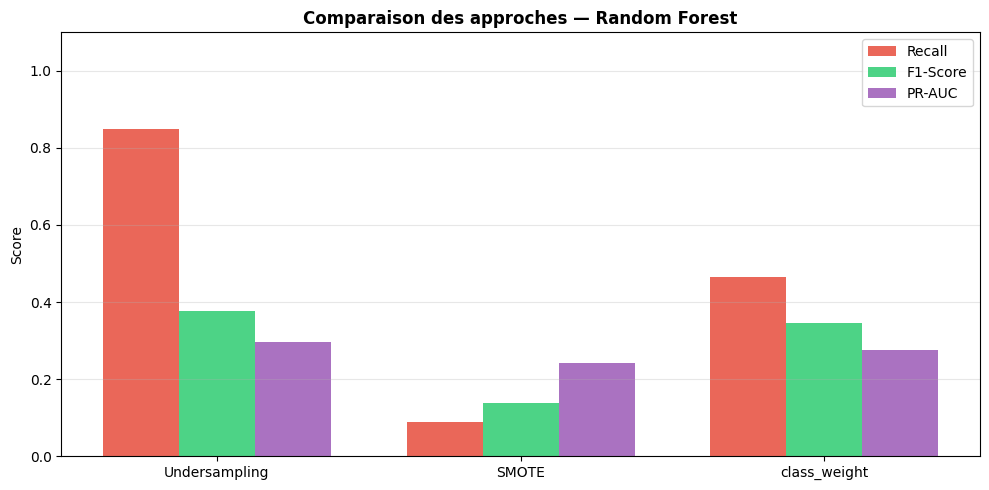

In [4]:
# APPROCHE NIVEAU MODÈLE — class_weight='balanced'

rf_clf_cw = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_cw.fit(X_train, y_train_clf)
y_pred_cw  = rf_clf_cw.predict(X_test)
y_proba_cw = rf_clf_cw.predict_proba(X_test)[:, 1]

print('=== Random Forest — class_weight=balanced ===')
print(f'   Accuracy  : {accuracy_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Precision : {precision_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Recall    : {recall_score(y_test_clf, y_pred_cw):.4f}')
print(f'   F1-Score  : {f1_score(y_test_clf, y_pred_cw):.4f}')
print(f'   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_cw):.4f}')
print(f'   PR-AUC    : {average_precision_score(y_test_clf, y_proba_cw):.4f}')

print('\n=== Comparaison des 3 approches ===')
header = f"{'Approche':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>8}"
print(header)
print('-' * 72)
for name, y_pred, y_proba in [
    ('Undersampling',        y_pred_under, y_proba_under),
    ('SMOTE',                y_pred_smote, y_proba_smote),
    ('class_weight=balanced',y_pred_cw,    y_proba_cw),
]:
    print(f'{name:<25} '
          f'{recall_score(y_test_clf, y_pred):>8.4f} '
          f'{precision_score(y_test_clf, y_pred):>10.4f} '
          f'{f1_score(y_test_clf, y_pred):>8.4f} '
          f'{roc_auc_score(y_test_clf, y_proba):>9.4f} '
          f'{average_precision_score(y_test_clf, y_proba):>8.4f}')

approaches = ['Undersampling', 'SMOTE', 'class_weight']
recalls    = [recall_score(y_test_clf, y_pred_under), recall_score(y_test_clf, y_pred_smote), recall_score(y_test_clf, y_pred_cw)]
f1s        = [f1_score(y_test_clf, y_pred_under),     f1_score(y_test_clf, y_pred_smote),     f1_score(y_test_clf, y_pred_cw)]
pr_aucs    = [average_precision_score(y_test_clf, y_proba_under), average_precision_score(y_test_clf, y_proba_smote), average_precision_score(y_test_clf, y_proba_cw)]

x = np.arange(len(approaches))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, recalls, width, label='Recall',  color='#e74c3c', alpha=0.85)
ax.bar(x,         f1s,     width, label='F1-Score', color='#2ecc71', alpha=0.85)
ax.bar(x + width, pr_aucs, width, label='PR-AUC',  color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des approches — Random Forest', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/rf_approaches_comparison.png', dpi=150)
plt.show()


## Matrice de Confusion — Comparaison Undersampling vs SMOTE

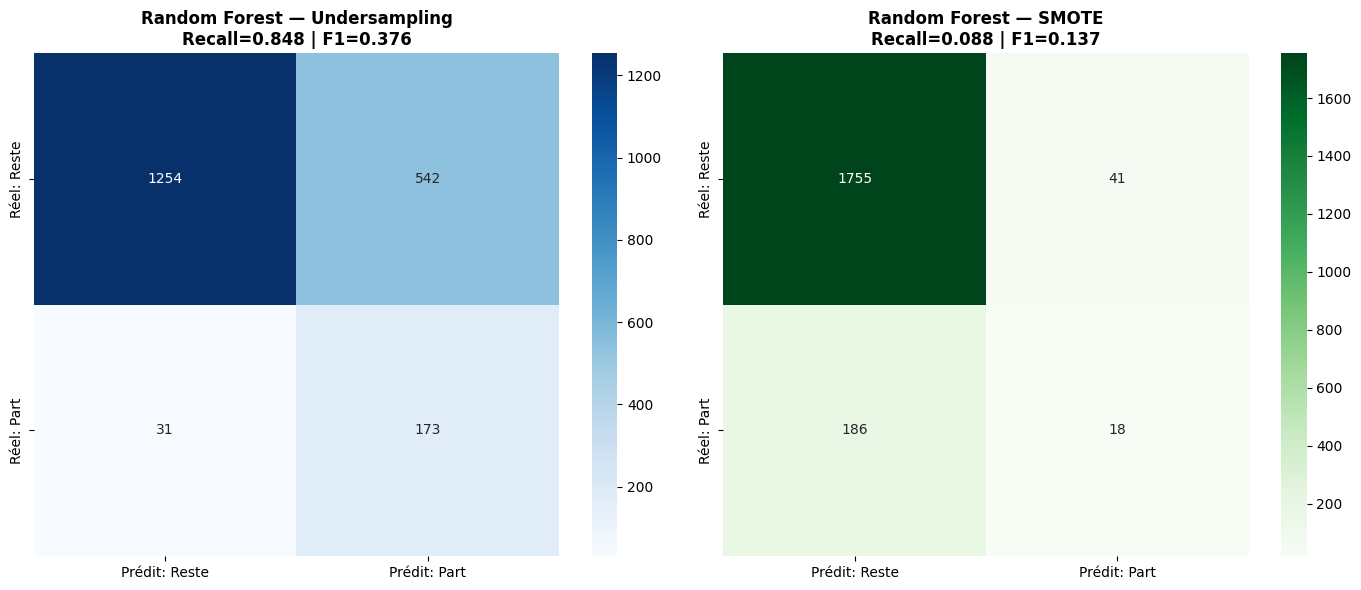


Meilleur modèle (Undersampling) :
   Vrais Négatifs  (TN) : 1254
   Faux Positifs   (FP) : 542
   Faux Négatifs   (FN) : 31 → churners manqués
   Vrais Positifs  (TP) : 173 → churners détectés


In [5]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'Random Forest — Undersampling', 'Blues'),
    (y_pred_smote, 'Random Forest — SMOTE', 'Greens'),
]):
    cm = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/rf_confusion_matrix.png', dpi=150)
plt.show()

# Détail meilleur modèle
cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   Vrais Négatifs  (TN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués")
print(f"   Vrais Positifs  (TP) : {tp} → churners détectés")

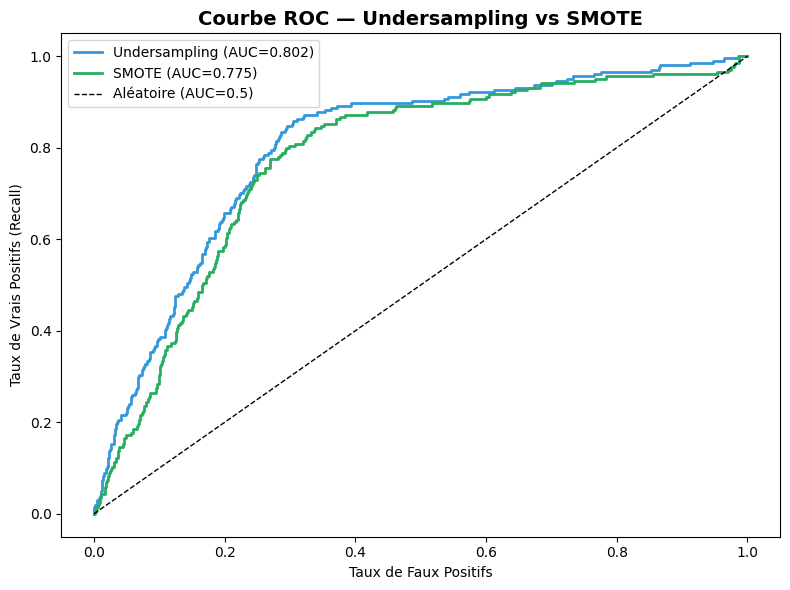

In [6]:
# COURBE ROC — Undersampling vs SMOTE

plt.figure(figsize=(8, 6))

for y_proba, label, color in [
    (y_proba_under, 'Undersampling', '#3498db'),
    (y_proba_smote, 'SMOTE',         '#27ae60'),
]:
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    auc_score = roc_auc_score(y_test_clf, y_proba)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Undersampling vs SMOTE', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/rf_roc_curve.png', dpi=150)
plt.show()

auc = roc_auc_score(y_test_clf, y_proba_clf)

## Ajustement du Seuil de Décision

Par défaut, un classifieur utilise un seuil de 0.5. Dans un contexte déséquilibré (10% de churners), ce seuil n'est pas optimal car il favorise la classe majoritaire.

On teste différents seuils et on mesure l'impact sur :
- **Recall** : taux de churners détectés (minimiser les FN)
- **Precision** : taux de vrais churners parmi les alertes (minimiser les FP)
- **F1-Score** : compromis precision/recall
- **FP / FN** : impact métier direct

Seuil par défaut (0.5) :
  Recall=0.848 | Precision=0.242 | F1=0.376 | FP=542 | FN=31

Seuil optimal (0.55) :
  Recall=0.784 | Precision=0.254 | F1=0.383 | FP=471 | FN=44


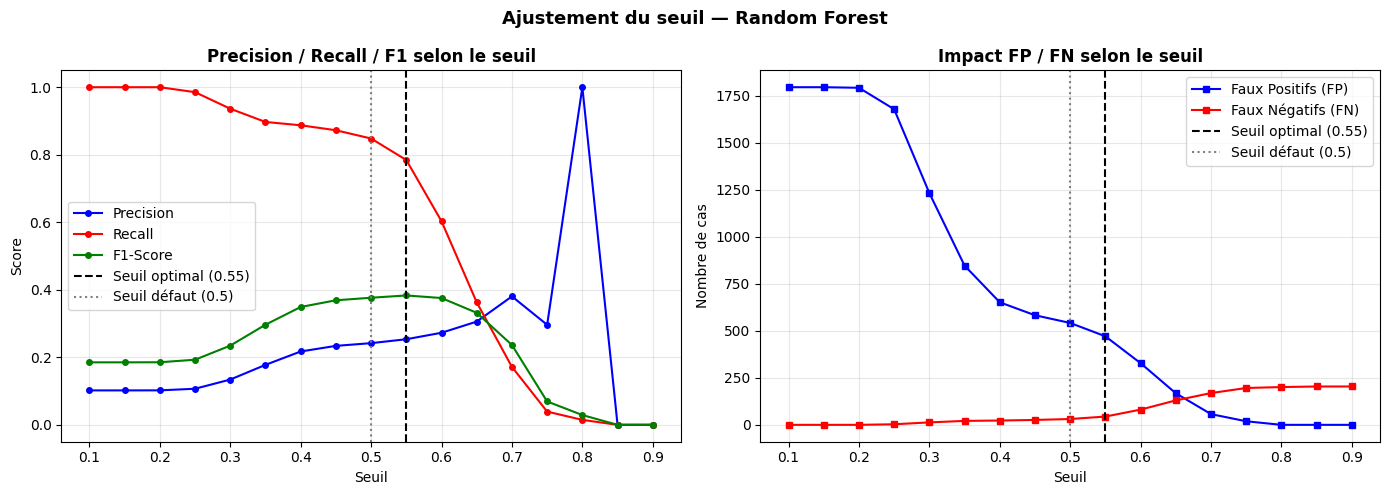

 seuil  precision   recall       f1   FP  FN  TP
  0.10   0.102000 1.000000 0.185118 1796   0 204
  0.15   0.102000 1.000000 0.185118 1796   0 204
  0.20   0.102153 1.000000 0.185370 1793   0 204
  0.25   0.106915 0.985294 0.192898 1679   3 201
  0.30   0.134129 0.936275 0.234644 1233  13 191
  0.35   0.177670 0.897059 0.296596  847  21 183
  0.40   0.217287 0.887255 0.349084  652  23 181
  0.45   0.233903 0.872549 0.368912  583  26 178
  0.50   0.241958 0.848039 0.376496  542  31 173
  0.55   0.253566 0.784314 0.383234  471  44 160
  0.60   0.272727 0.602941 0.375573  328  81 123
  0.65   0.305785 0.362745 0.331839  168 130  74
  0.70   0.380435 0.171569 0.236486   57 169  35
  0.75   0.296296 0.039216 0.069264   19 196   8
  0.80   1.000000 0.014706 0.028986    0 201   3
  0.85   0.000000 0.000000 0.000000    0 204   0
  0.90   0.000000 0.000000 0.000000    0 204   0

Prédictions mises à jour avec seuil=0.55
  Recall final  : 0.7843
  F1 final      : 0.3832


In [7]:
# AJUSTEMENT DU SEUIL DE DÉCISION

thresholds = np.arange(0.1, 0.91, 0.05)

results_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_clf >= t).astype(int)
    cm_t = confusion_matrix(y_test_clf, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'seuil':     round(t, 2),
        'precision': precision_score(y_test_clf, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test_clf, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test_clf, y_pred_t, zero_division=0),
        'FP':        int(fp_t),
        'FN':        int(fn_t),
        'TP':        int(tp_t),
    })

df_thresh = pd.DataFrame(results_thresh)

# Seuil optimal = max F1
best_idx = df_thresh['f1'].idxmax()
best_t   = df_thresh.loc[best_idx, 'seuil']

# Affichage comparaison seuil 0.5 vs optimal
rows_05 = df_thresh[df_thresh['seuil'] == 0.5]
if len(rows_05) > 0:
    r05 = rows_05.iloc[0]
    print(f"Seuil par défaut (0.5) :")
    print(f"  Recall={r05['recall']:.3f} | Precision={r05['precision']:.3f} | F1={r05['f1']:.3f} | FP={int(r05['FP'])} | FN={int(r05['FN'])}")

br = df_thresh.loc[best_idx]
print(f"\nSeuil optimal ({best_t}) :")
print(f"  Recall={br['recall']:.3f} | Precision={br['precision']:.3f} | F1={br['f1']:.3f} | FP={int(br['FP'])} | FN={int(br['FN'])}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['seuil'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
axes[0].plot(df_thresh['seuil'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
axes[0].plot(df_thresh['seuil'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
axes[0].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_thresh['seuil'], df_thresh['FP'], 'b-s', markersize=4, label='Faux Positifs (FP)')
axes[1].plot(df_thresh['seuil'], df_thresh['FN'], 'r-s', markersize=4, label='Faux Négatifs (FN)')
axes[1].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[1].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title('Impact FP / FN selon le seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ajustement du seuil — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_threshold_analysis.png', dpi=150)
plt.show()

print(df_thresh.to_string(index=False))

# Mise à jour des prédictions finales avec le seuil optimal
y_pred_clf = (y_proba_clf >= best_t).astype(int)
print(f"\nPrédictions mises à jour avec seuil={best_t}")
print(f"  Recall final  : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"  F1 final      : {f1_score(y_test_clf, y_pred_clf):.4f}")


## Validation Croisée Stratifiée (Stratified K-Fold)

Un simple split train/test peut être sensible au hasard de la partition. La validation croisée stratifiée permet d'obtenir une estimation plus robuste des performances en préservant les proportions de classes (10% churners) dans chaque fold.

**Pourquoi stratifiée ?**  
Avec seulement 10% de churners, un fold non stratifié pourrait se retrouver avec très peu (ou aucun) churner, rendant les métriques instables.

On évalue le meilleur modèle (issu de la comparaison Undersampling vs SMOTE) sur 5 folds stratifiés et on reporte mean ± std pour chaque métrique.

Stratified K-Fold (5 folds) — Random Forest
--------------------------------------------------
  recall       : 0.0588 ± 0.0176
  precision    : 0.2873 ± 0.0304
  f1           : 0.0967 ± 0.0258
  roc_auc      : nan ± nan
  pr_auc       : nan ± nan

Comparaison avec le score test set (seuil optimisé) :
  recall     : 0.7843  (test set)
  f1         : 0.3832  (test set)
  roc_auc    : 0.8024  (test set)
  pr_auc     : 0.2974  (test set)


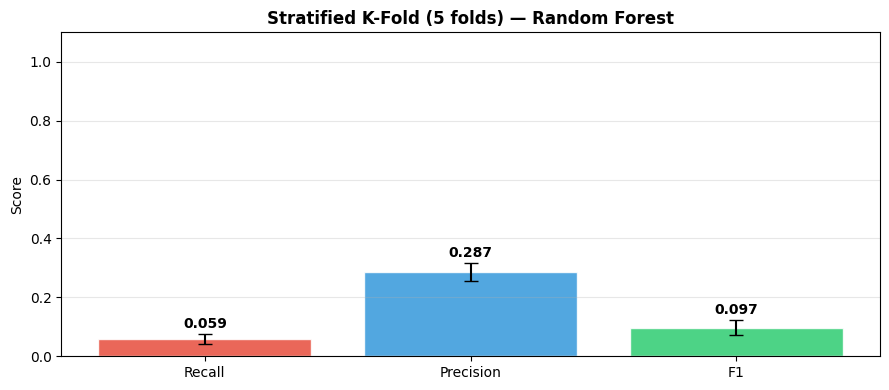

In [8]:
# VALIDATION CROISÉE STRATIFIÉE — Stratified K-Fold

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1':        make_scorer(f1_score),
    'roc_auc':   make_scorer(roc_auc_score, needs_proba=True),
    'pr_auc':    make_scorer(average_precision_score, needs_proba=True),
}

# Pipeline : rééquilibrage SMOTE à l'intérieur du fold (évite le data leakage)
pipe = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('clf',     RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1)),
])

cv_results = cross_validate(
    pipe,
    X_train, y_train_clf,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print(f'Stratified K-Fold ({N_SPLITS} folds) — Random Forest')
print('-' * 50)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

# Comparaison avec le score sur le test set
print('\nComparaison avec le score test set (seuil optimisé) :')
print(f'  recall     : {recall_score(y_test_clf, y_pred_clf):.4f}  (test set)')
print(f'  f1         : {f1_score(y_test_clf, y_pred_clf):.4f}  (test set)')
print(f'  roc_auc    : {roc_auc_score(y_test_clf, y_proba_clf):.4f}  (test set)')
print(f'  pr_auc     : {average_precision_score(y_test_clf, y_proba_clf):.4f}  (test set)')

# Visualisation mean ± std
metrics_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_keys   = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
means = [cv_results[f'test_{k}'].mean() for k in metrics_keys]
stds  = [cv_results[f'test_{k}'].std()  for k in metrics_keys]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics_labels, means, yerr=stds, capsize=5,
              color=['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22'],
              edgecolor='white', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Stratified K-Fold (5 folds) — Random Forest', fontweight='bold')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/rf_kfold_cv.png', dpi=150)
plt.show()


## Feature Importance


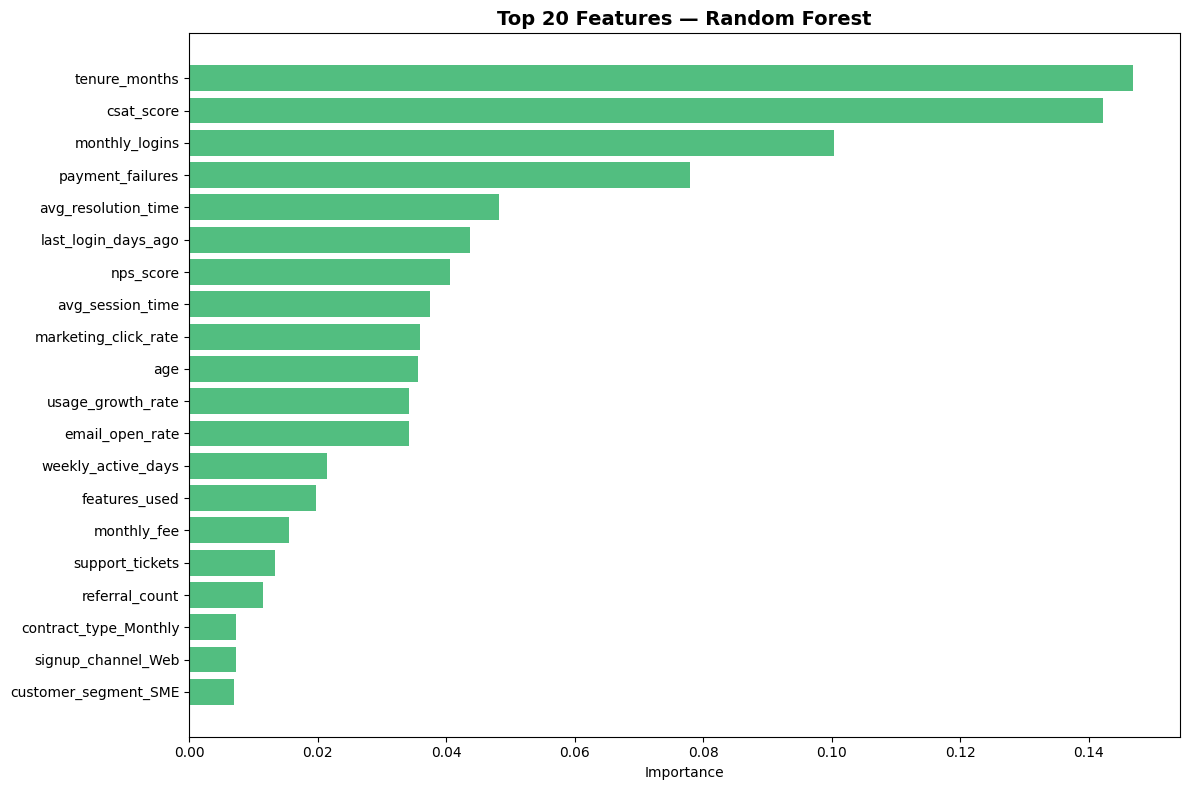


🔝 Top 10 features les plus importantes :
   1. tenure_months                       : 0.1469
   2. csat_score                          : 0.1423
   3. monthly_logins                      : 0.1004
   4. payment_failures                    : 0.0780
   5. avg_resolution_time                 : 0.0482
   6. last_login_days_ago                 : 0.0437
   7. nps_score                           : 0.0407
   8. avg_session_time                    : 0.0375
   9. marketing_click_rate                : 0.0359
   10. age                                 : 0.0356


In [9]:
# FEATURE IMPORTANCE

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(12, 8))
plt.barh(range(20), 
         importances[indices][::-1],
         color='#27ae60', alpha=0.8)
plt.yticks(range(20), 
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — Random Forest',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=150)
plt.show()

print("\n🔝 Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression du Revenu à Risque


In [10]:
# VÉRIFICATION AVANT ENTRAÎNEMENT
X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')

print("Vérification des données régression :")
print(f"  X_train_reg shape : {X_train_reg.shape}")
print(f"  y_train_reg_log shape : {y_train_reg_log.shape}")
print(f"  y_train_reg_log min : {y_train_reg_log.min():.2f}")
print(f"  y_train_reg_log max : {y_train_reg_log.max():.2f}")
print(f"  y_test_reg shape : {y_test_reg.shape}")
print(f"  y_test_reg — nb zeros : {(y_test_reg == 0).sum()}")
print(f"  y_test_reg — nb churners : {(y_test_reg > 0).sum()}")

# Vérifier que total_revenue n'est PAS dans X_train_reg
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()
print(f"\n  Features contenant 'revenue' : {[f for f in feature_names if 'revenue' in f.lower()]}")
print(f"  Features contenant 'total' : {[f for f in feature_names if 'total' in f.lower()]}")

Vérification des données régression :
  X_train_reg shape : (817, 50)
  y_train_reg_log shape : (817,)
  y_train_reg_log min : 2.40
  y_train_reg_log max : 8.61
  y_test_reg shape : (2000,)
  y_test_reg — nb zeros : 1796
  y_test_reg — nb churners : 204

  Features contenant 'revenue' : []
  Features contenant 'total' : []


In [11]:
# TÂCHE 2 — RÉGRESSION Random Forest

X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,          # réduit (était 10)
    min_samples_leaf=20,  # augmenté (était 5) → force la généralisation
    max_features=0.5,     # utilise seulement 50% des features par split
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train_reg, y_train_reg_log)

y_pred_reg_log = rf_reg.predict(X_test)
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

churners_test_mask = y_test_reg > 0
mae  = mean_absolute_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])
rmse = np.sqrt(mean_squared_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask]))
r2   = r2_score(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])

print("Modèle de régression entraîné !")
print(f"\nRésultats — Random Forest Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — Random Forest Regression (churners uniquement)
   MAE  : 181.89 €
   RMSE : 434.38 €
   R²   : 0.7911


In [12]:
# SAUVEGARDE

# Sauvegarde du meilleur modèle (sélectionné automatiquement)
print(f"Sauvegarde du modèle : {best_technique}")
joblib.dump(rf_clf, '../models/rf_classification.pkl')
joblib.dump(rf_reg, '../models/rf_regression.pkl')

results_clf = {
    'model'    : 'Random Forest (' + best_technique + ')',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf),
    'pr_auc'  : average_precision_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Random Forest Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/rf_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/rf_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du modèle : Undersampling
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

Résumé Classification :
   accuracy   : 0.7425
   precision  : 0.2536
   recall     : 0.7843
   f1         : 0.3832
   roc_auc    : 0.8024
   pr_auc     : 0.2974


## Synthèse — Random Forest
